# **Directed percolation in Rust-Python**

First stab at implementing DP in Rust with a Python convenience wrapper.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from numpy.typing import NDArray
from dprs import sim
from typing import Any

In [2]:
params = dict(
    n_x = 121, #3_000,
    n_y = 81, #5_000,
    # n_z = 1,
    p = 0.5,
    n_iterations = 100,
    serial_skip = 10,
    n_threads = 16,
)

Execute the Rust-coded sim:

In [3]:
n_lattices: int
raw_lattices: list[list] 
(n_lattices, raw_lattices,)= sim.dp(**params)


Dimension:   D2
Grid shape:  (121, 81, 1)
Probability: 0.5
Iterations:  100
Sample rate: 10
Serial skip: 10
Threads:     16

Serial:   0.004s
Parallel: 0.012s
Chunked:  0.004s

Parallel speedup => 0.32x
Chunked speedup =>  1.01x



`sim.dp` returns a subset of the time-series of lattices generated by the model run, where the subsetting rate is given by the `sample_rate` parameter, and where the total number returned is `n_lattices`. Each lattice is given in flattened form as a 1d list, with all the lattices concatenated into one long 1d list.


Next, we convert this long list into a 1+2d numpy array, with the last index being the lattice slice number.

In [4]:
lattices: NDArray = np.array(raw_lattices, dtype=np.bool,) \
                .reshape(n_lattices, params["n_y"], params["n_x"], ).T
lattices.shape

(121, 81, 11)

Function to plot the lower-left portion of the lattice:

In [5]:
def image_lattice(
        lattices: NDArray, i_lattice: int=0, x: int=121, y: int=81,
    ) -> tuple[Figure, Any]:
    fig = plt.figure()
    color_map = ListedColormap(((0.8, 0.8, 0.8,), (0.7, 0, 0.7),))
    plt.imshow(
        lattices[0:x, 0:y, i_lattice,].T, 
        cmap=color_map, origin="lower",
    )
    color_bar = plt.colorbar(
        ticks=(0.25, 0.75,), 
        shrink=0.5*(params["n_y"]/params["n_x"])**0.25, 
        aspect=15,
    )
    color_bar.set_ticklabels((0, 1,),)
    plt.grid(ls=":")
    return fig, plt

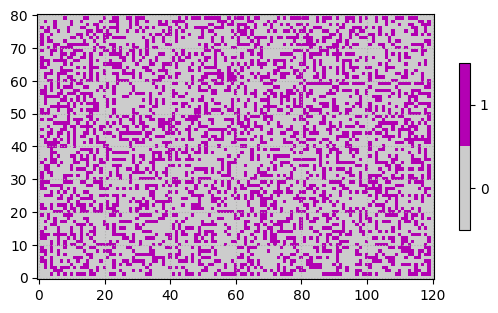

In [6]:
fig, plt = image_lattice(lattices, 10,)
plt.show()